# Explainable Credit Risk Assessment


## 1. Load the Data
* We will bring in the loan application data.
* This data has details like income, age, and loan mount.
* It also tells us who repaid and who defaulted.

In [338]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [339]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Exploration Data Analysis(EDA)
   * Here we simply look at the data before touching it.
   * We want to understand it first, then work on it.


### Basic info about the data
* Cheak how many rows and columns we have
* Cheak the data type of the each column

In [340]:
df.shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


### Missing values
* Find out which columns have the empty or missing values.\
* This tells us where we may need to fix things later.

In [341]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### Target balance
* Cheak how many people defaulted vs how many repaid.
* This tells us if our data is balanced oe imbalanced.

In [342]:
df.head()
df['loan_status'].unique()

df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

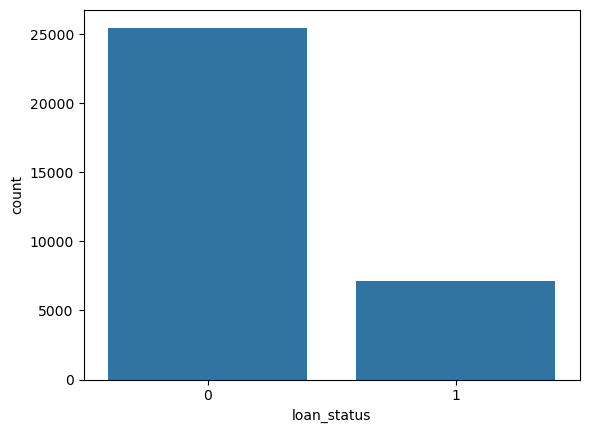

In [343]:
sns.countplot(x='loan_status', data=df)

### Outlier cheak
* Look for the values that seem impossible, like age 144.
* These are signs of the bad entries.

In [344]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


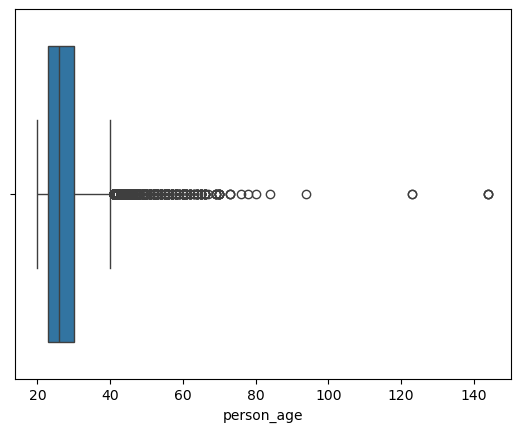

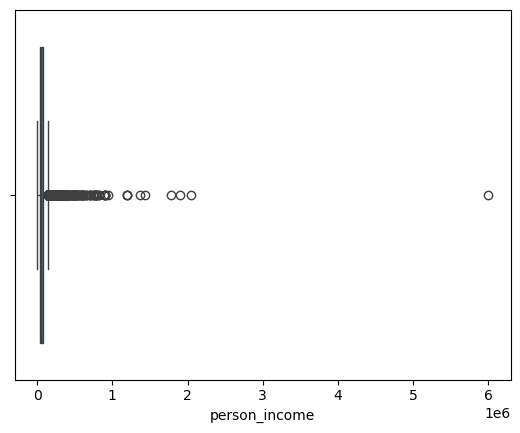

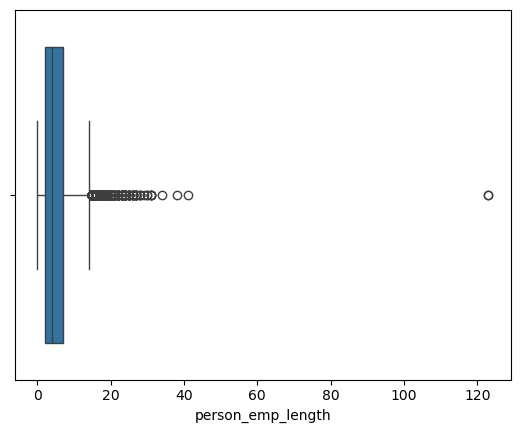

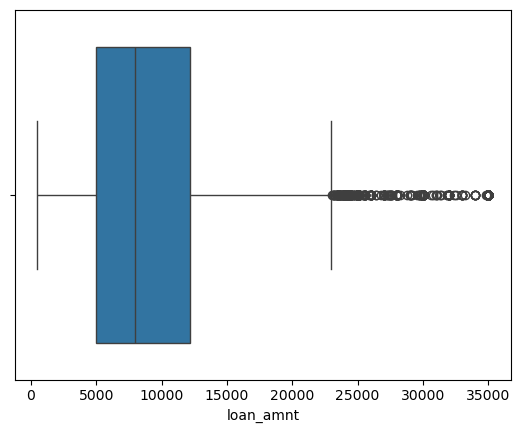

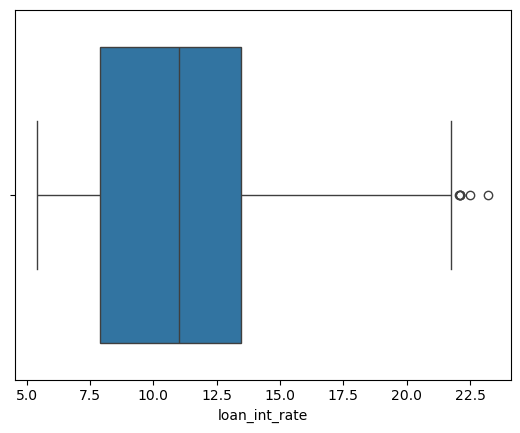

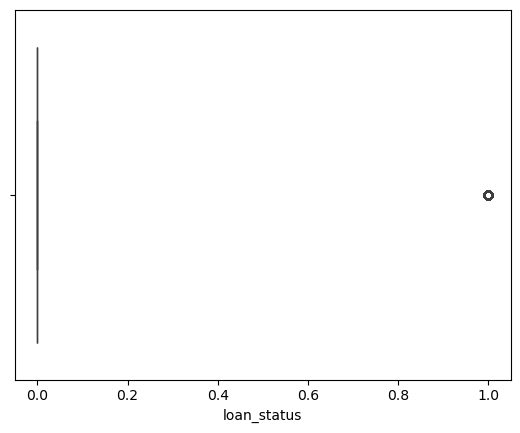

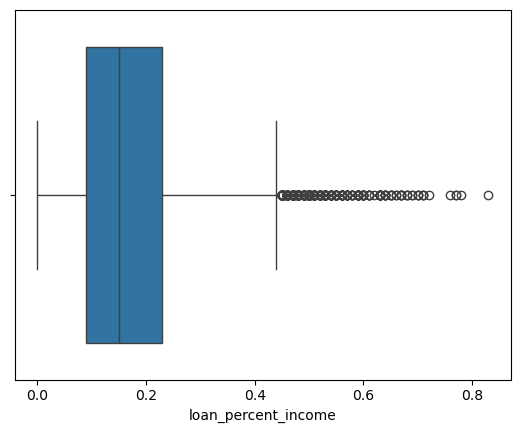

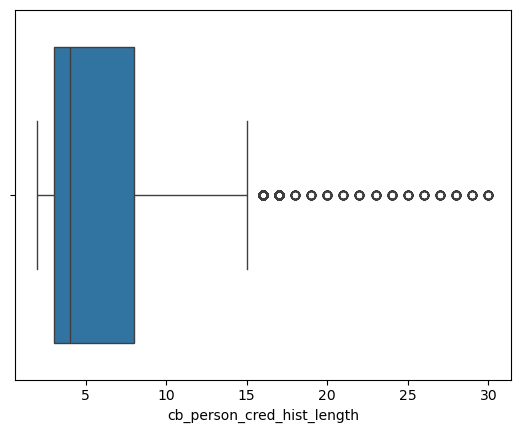

In [345]:
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
    sns.boxplot(x=df[i])
    plt.show()    

In [346]:
(df['person_age']>100).sum()

np.int64(5)

In [347]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [348]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Correlation cheak
* See how strongly features are related to each other.
* This help us spot repeated or linked information.

<Axes: >

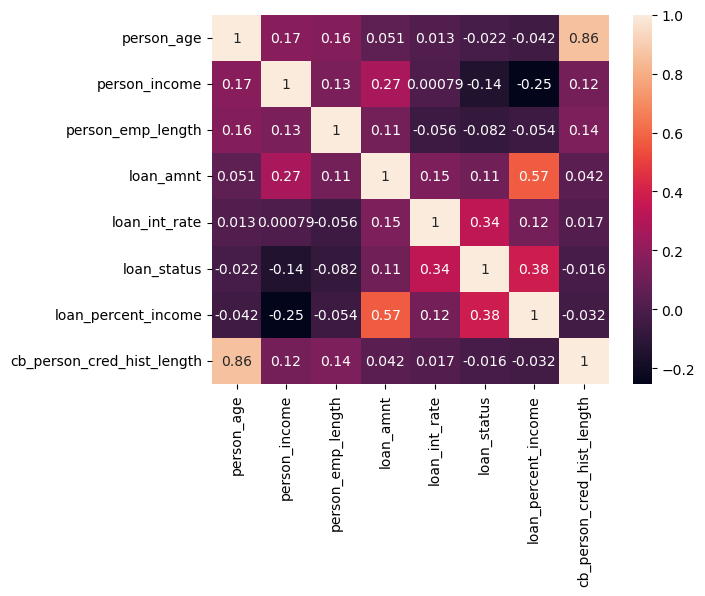

In [349]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## 3. Data Validation & Outlier Handling
* Here we clean the data properly.
* We remove dublicate rows.
* we remove rows with an impossible age or work experience.
* We remove rows with zero or negative income and loan amounts.
* We cheak if the interest rate looks realistic.
* We also flag rows where numbers dont't add up correctly.

In [350]:
# Coping the data we never use the real data set to manipulate.
df_copy = df.copy()

In [351]:
# Original Rows 
print(f"Original Rows: {df_copy.shape[0]}")

# Remove Duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates: {df_copy.shape[0]}")

Original Rows: 32581
Rows after removing duplicates: 32416


In [352]:
# Removing ages below 18 or over 100
df_copy = df_copy[df_copy['person_age']>=18]
df_copy = df_copy[df_copy['person_age']<=100]

In [353]:
# Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

In [354]:
# Remove the rows with zero or -ve income and loan amount.
df_copy = df_copy[df_copy['loan_amnt']>0]

In [355]:
# Cheak if the interst rate looks realistic
print("Loan intrest rate range from (min: 5.42 and max: 23.22)")

Loan intrest rate range from (min: 5.42 and max: 23.22)


## 4. Feature, Target & Train-Test Split
* We seprate the data into input features and the target.
* The target is whether the applicant defaulted or not.
* We split the data into a training part and a testing part.
* The model learnes from the training part only.

In [356]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']

In [357]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [358]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## 5. Handle Class Imbalance
* Very few people actually default in this data.
* If we ignore this, the model may just favor the majourity class.
* We give more importance to the minority class during the traning.
* This help the model actually learn to spot defaulters.

In [359]:
# 0 - no loan (most)
# 1 - yes loan

neg, pos = np.bincount(y_train)
scale_weights = neg/pos

In [360]:
scale_weights

np.float64(3.6312213039485766)

## 6. Data Preprocessing -- Pipelines & Column Transformwe
* Raw data is not ready for the model directly.
* We need to prepare numeric and test columns differently.
* We will build the Pipeline for the each model.
* We will use CommonTransformer to apply different steps to different columns

### Preprocesssing for Logical Regression
* Fill missing numeric values.
* Scale numeric values, since this model is sensitive to scale.
* Converte the catorory columns into number using one hot encoding.

In [361]:
#Logistic Regression : impute + SCALE Numeric, impute + One-Hot-Encoding

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        # Pipeline - for numberical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        # Pipline - for categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)    

### Preprocessing for XGBoost
* Fill missing numberic values.
* No scaling needed here, scince tree model dont't need it.
* Convert category columns into numbers uning one hot encoding

In [362]:
# XGBoost : Impute numbericl only (No scaling), impute + One Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        # Pipeline - for numberical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        # Pipline - for categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)    

## 7. Evaluate Helper Function
* We build one common function to cheak any module's performance.
* It will show accuracy, precision, recall, F1 score, and more.
* It will also show a confusion matrix and a precision recall curve.

## 8. Stratified Cross Validation
* One single train test may not be reliable.
* We split the taining data into five fold instead.
* Each fold keeps the same default vs repaid ratio.
* We cheak the model's score across all folds.

In [364]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring= {'roc_auc':'roc_auc', 'accuracy': 'accuracy', 'precision':'precision', 'recall': 'recall', 'f1':'f1'}

In [365]:
# Logestic Regression

from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced',random_state=42))
])

lr_cv_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [366]:
# XGboost Model
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight = scale_weights, random_state=42
    ))
])

xgb_cv_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [367]:
for cv_name, pipe in [
    ("Logistic Regression", lr_cv_pipeline),
    ("XGBoost", xgb_cv_pipeline)
]:

    cv_results = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    print(cv_name)
    print(f"ROC-AUC: {cv_results['test_roc_auc'].mean()}")
    print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
    print(f"Precision: {cv_results['test_precision'].mean()}")
    print(f"Recall: {cv_results['test_recall'].mean()}")
    print(f"F1: {cv_results['test_f1'].mean()}")
    print("")


Logistic Regression
ROC-AUC: 0.8705112830525306
Accuracy: 0.8115949542892269
Precision: 0.5448226008889892
Recall: 0.7781450872359963
F1: 0.6408013995933108

XGBoost
ROC-AUC: 0.9393848243386111
Accuracy: 0.9086724038455642
Precision: 0.7913354492271174
Recall: 0.7856749311294765
F1: 0.7880291923045915



## 9. Baseline Model -- Logestic Regression
* We start with a simple model first.
* This become our benchmark to beat.
* We train it and cheak its score on the test data.

In [368]:
baseline_model = Pipeline(steps=[
    ('Preprocessor', preprocessor_lr),
    ('Classifier', LogisticRegression(class_weight='balanced'))
])
baseline_model.fit(X_train, y_train)

,steps,"[('Preprocessor', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluate the Logistic Model.

In [1]:
evaluate_model("Baseline Logistic Model", baseline_model, X_test, y_test)

NameError: name 'evaluate_model' is not defined

## 10. XGBoost Hyperparameter Tuning
* Now we move to a stronger model, XXGBoost.
* A model has a many settngs called hyperparameters.
* We search for the best combination of here settings.
* We use cross validation while searching, so the result is reliable.

In [370]:
xg_model = Pipeline([
    ('preprocessing', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,
         scale_pos_weight=scale_weights,random_state=42))
])
xg_model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Accuracy: 0.92
Precision: 0.82
Recall: 0.79
F1: 0.81

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4943
           1       0.82      0.79      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



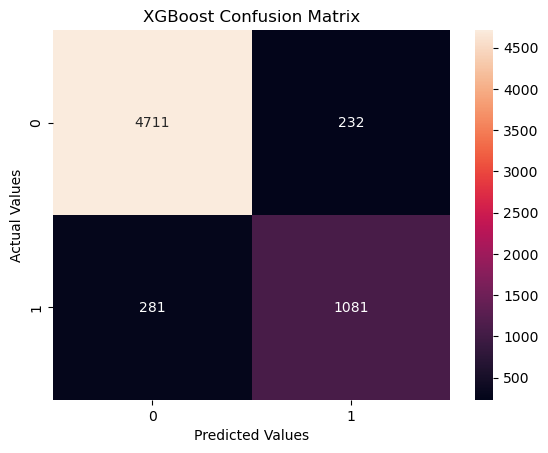

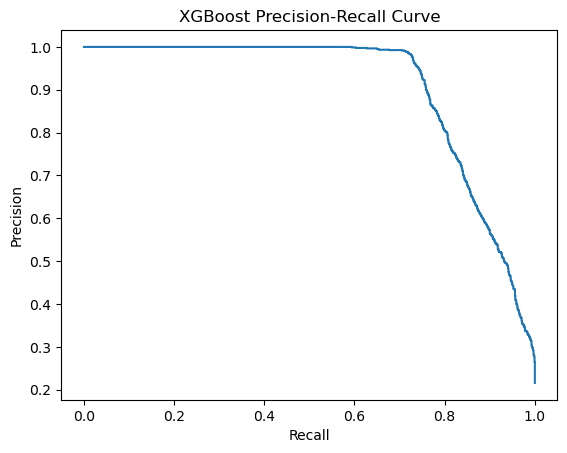

In [371]:
evaluate_model("XGBoost", xg_model, X_test, y_test)

In [372]:
from scipy.stats import uniform, randint

In [373]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth": randint(3, 9),
    "classifier__learning_rate": uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6, 0.4), # Rows sampling
    "classifier__colsample_bytree": uniform(0.6, 0.4), # Columns sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0, 5)

}
# lower gamma --> more splits --> complex tree --> higher overfitting risk
# higher gamma --> less splits --> simpler tree --> low ovwefitting

In [374]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs = -1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': <scipy.stats....001CA9CF68050>, 'classifier__gamma': <scipy.stats....001CA9CF699A0>, 'classifier__learning_rate': <scipy.stats....001CCAA74FE50>, 'classifier__max_depth': <scipy.stats....001CCA911A9C0>, ...}"
,n_iter,150
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [375]:
print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.90


In [376]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.7390585895857514),
 'classifier__gamma': np.float64(0.06434624072074457),
 'classifier__learning_rate': np.float64(0.10238678477845735),
 'classifier__max_depth': 6,
 'classifier__min_child_weight': 2,
 'classifier__n_estimators': 294,
 'classifier__subsample': np.float64(0.9184080677874001)}

## 11. Compare Both Models Side by Side
* We now compare Logistic Regression And XGBoost.
* We look at their scores together in one table.
* This helps us pick the better performing model.

Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1: 0.65

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



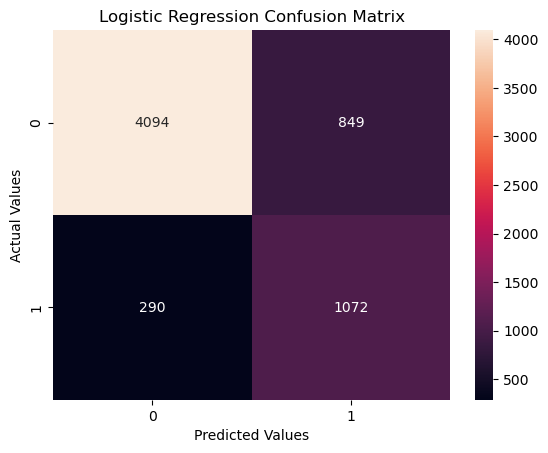

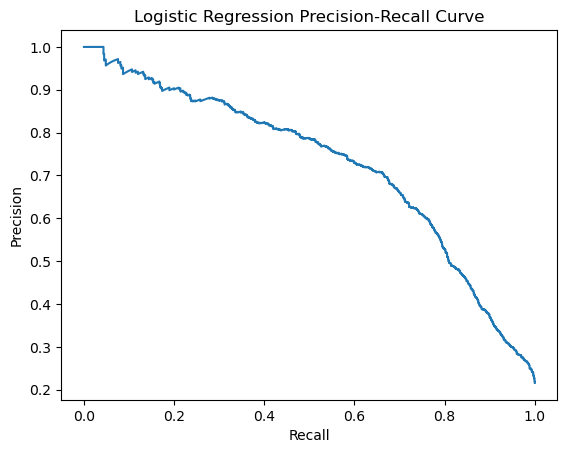

In [377]:
evaluate_model("Logistic Regression", baseline_model, X_test, y_test)

Accuracy: 0.92
Precision: 0.84
Recall: 0.80
F1: 0.82

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4943
           1       0.84      0.80      0.82      1362

    accuracy                           0.92      6305
   macro avg       0.89      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



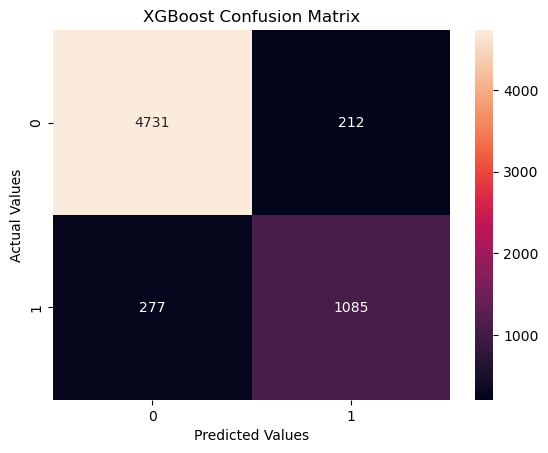

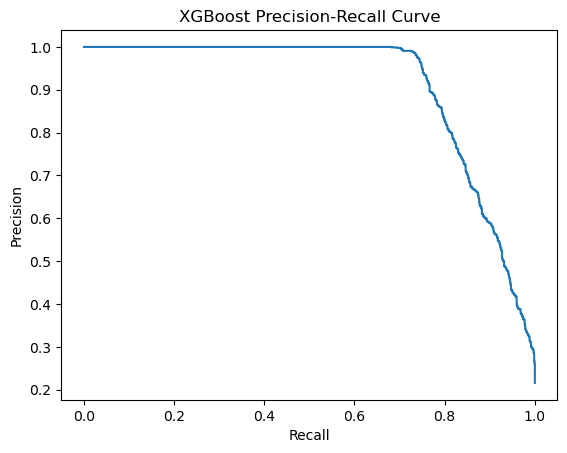

In [378]:
# Passing the XGBoost model after performing Hyperparameter Tuning 
evaluate_model("XGBoost", random_search, X_test, y_test)

## 12. Optimizing the Classification Threshold
* The model gives a probability, not a direst yess or no
* We decide a cut off point to turn it in the decision.
* We cheak different cut-off points and pick the best one.

c:\Users\Acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Acer\anaconda3\Lib\site-packag

Accuracy: 0.78
Precision: 0.00
Recall: 0.00
F1: 0.00

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4943
           1       0.00      0.00      0.00      1362

    accuracy                           0.78      6305
   macro avg       0.39      0.50      0.44      6305
weighted avg       0.61      0.78      0.69      6305



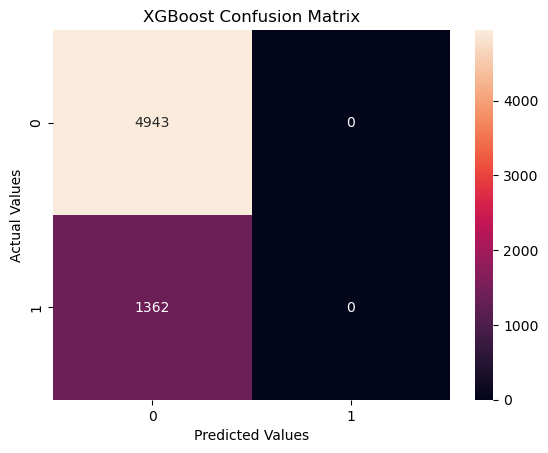

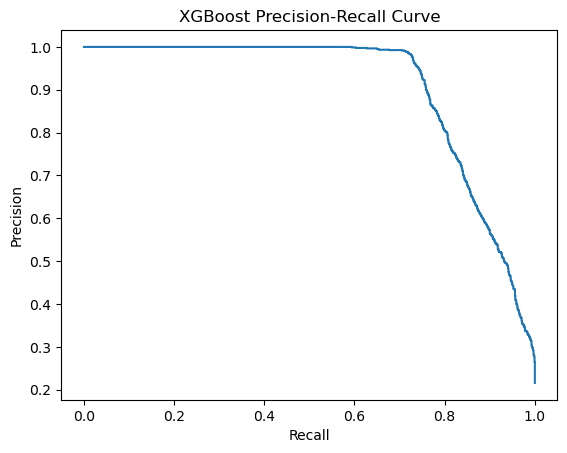

In [379]:
# Get the prob. of the classs 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

# For each threshold calculate Precision and Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, prob)

# Calculate F1 score for each threshold
f1 = 2*(precisions - recalls) / (precisions + recalls + 1e-9)

# Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

# Evaluate the XGBoost model using that threshold.
evaluate_model("XGBoost", xg_model, X_test, y_test, best_threshold )

## 13. Probability Calibration
* Sometimes a model's probability doesn't mean what it says.
* For example, 30% risk should truly means a 30% chance.
* We cheak this with the calibration plot.
* We fit it if the probabilities are off.

In [380]:
"""
Methods by which we can fix the poorly calibrated model.
1. Platt Scalling/ Sigmoid --> Adjust the probabilities using a sigmoid curve.
2. Isotonic Regression --> Learn a flexible mapping from old prob. - better brop.(non linear)
3. Temperature Scaling --> Adjusting the confidence of neural-network prediction using one temperature.
"""

'\nMethods by which we can fix the poorly calibrated model.\n1. Platt Scalling/ Sigmoid --> Adjust the probabilities using a sigmoid curve.\n2. Isotonic Regression --> Learn a flexible mapping from old prob. - better brop.(non linear)\n3. Temperature Scaling --> Adjusting the confidence of neural-network prediction using one temperature.\n'

### 1. Calibrated XGBoost Model

In [381]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=5
)
calibrated_model.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


### 2. Get probabilites

In [382]:
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

### 3. Create calibrated curves

In [383]:
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [384]:
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins=10)

### 4. Plot

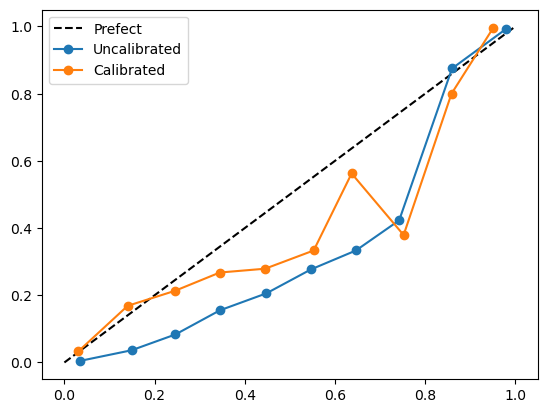

In [385]:
plt.plot([0,1], [0,1], 'k--', label="Prefect")

plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"

)
plt.legend()

### 14. SHAP Interpretation -- Global & Local
* SHAP helps us understand why the model makes a decision
* It is way of explaining a "black box" model

In [386]:
# 1. Install SHAP if not exists
!pip install shap

In [387]:
import shap

### 2. Get the trained XGBoost classifier model out of the pipeline

In [388]:
xgb_classifier = xg_model.named_steps['classifier']

### 3. Transorm X_test using the same preprocessing used for training.



In [389]:
X_test_transformed = xg_model.named_steps['preprocessing'].transform(X_test)

### 4. Get feature names after one hot encoder, so plots are readable

In [390]:
feature_names = xg_model.named_steps['preprocessing'].get_feature_names_out()

### 5. Convert to a dataframe for cleaner SHAP plots

In [391]:
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

### 6. Create SHAP explainer built for tree based model

In [392]:
explainer = shap.TreeExplainer(xgb_classifier)

### 7. Calculate SHAP values for every row in the test set

In [393]:
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.7525564e-01, -1.0555401e-01,  1.2984274e-01, ...,
        -7.3516299e-03, -3.8879909e-02,  0.0000000e+00],
       [ 4.7165085e-02, -8.7262326e-01, -9.4737314e-02, ...,
        -9.2151780e-03, -7.5508673e-03,  0.0000000e+00],
       [ 7.8027323e-02,  3.5025654e+00,  1.2711690e-01, ...,
        -7.3584518e-03,  7.7456667e-04,  0.0000000e+00],
       ...,
       [-8.6244913e-03,  5.8208084e-01,  7.2391242e-02, ...,
        -9.2837382e-03, -1.1459960e-02,  0.0000000e+00],
       [ 2.0838849e-02, -1.0313793e+00,  4.3692421e-02, ...,
        -9.2305308e-03, -1.1398584e-02,  0.0000000e+00],
       [-1.3665082e-01, -5.0866711e-01,  2.6854105e-02, ...,
        -8.8342456e-03, -1.0388625e-02,  0.0000000e+00]],
      shape=(6305, 26), dtype=float32)

## Global Explanation
* This shows whoch feature matter most overall.
* It also shows if a feature increases or decreases risk.

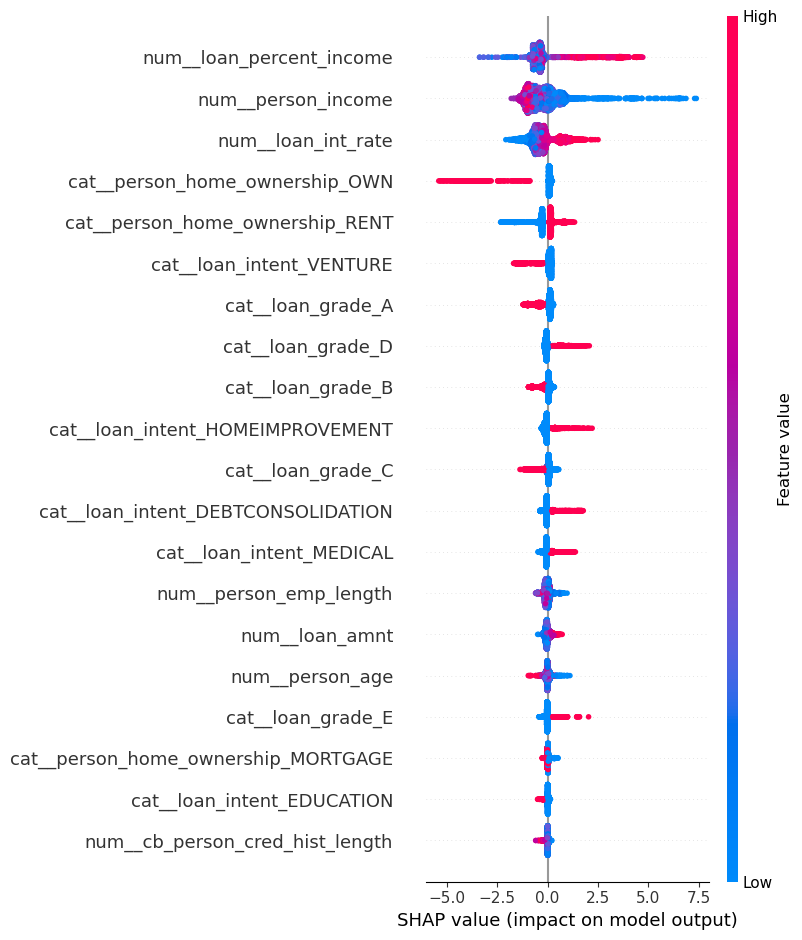

In [394]:
shap.summary_plot(shap_values, X_test_df)

## Local Explanation
* This shows why one specific application got their score.
* It breaks the score down feature by feature.

### 1. Pick one row to explain , e.g the 5th applicant in thr test set

In [395]:
row_index = 5

### 2. Draw a waterfall plot showing how each feature pushed the prediction up and down

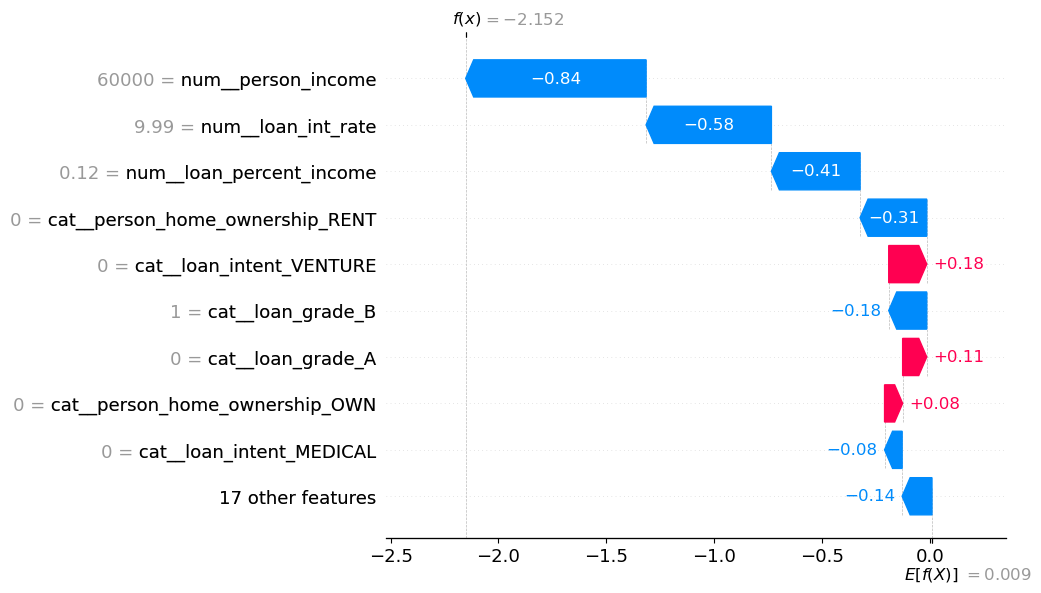

In [396]:
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

## 15. Analyzing False Positive & False Negative
* The model will not be perfect.
* False positive are safe people wrongly marked risky.
* False negative are risky people wrongly marked safe.
* We study these cases to understand where the model struggle.

### Get predictions from the best performing XGBoost model on the test set

In [397]:
y_pred = random_search.predict(X_test)

### Create a dataframe to easily compare the actual and predicted values

In [398]:
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

### Identify False Positive : model predicted 1, but actual was 0

In [399]:
false_positive = result_df[(result_df['actual'] == 0) & (result_df['predicted']==1)]


### Identify False Negative : model prediction 0, but actual was 1

In [400]:
false_negative = result_df[(result_df['actual'] == 1) & (result_df['predicted']==0)]

In [401]:
print(f"False Positive:  {len(false_positive)}")
print(f"False Negative:  {len(false_negative)}")

False Positive:  212
False Negative:  277


In [402]:
# False Negative > False Positive

### 16. Save the Final Model
* Once we are happy with the model, we save it
* We alse save the settings it needs, like the chossen threshold.
* This saved file can now be used in a real project.

In [404]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [405]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']

In [406]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Get probabilities from the CALIBRATED model, not the old xg_model
calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

# 2. Re run the same threshold search,  now on the correct probability scale
precisions, recalls, thresholds = precision_recall_curve(y_test, calibrated_proba)
f1_scores = 2*(precisions*recalls)/(precisions+recalls+1e-9)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("New threshold:", best_threshold)

New threshold: 0.5981149978473859


In [407]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']